# Inference for Regression: Boostrapping

Complete this problem set with your group (up to 4 students). You can either hand-write your work and submit a hard copy, or go to File -> Download as HTML to generate an HTML file, then either submit it online or as a hard copy. Each group only needs to submit one copy and will receive the same grade. 

This team homework is based on Lecture 33: Regression Inference. 

**Helpful Resource:**
- [Python Reference](http://data8.org/sp22/python-reference.html): Cheat sheet of helpful array & table methods used in Data 8!

**Recommended Readings**: 
- [Regression Inference](https://inferentialthinking.com/chapters/16/Inference_for_Regression.html)


In [1]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
from math import ceil

We'll combine two ideas from previous chapters: inference through bootstrapping, and the least square regression model. Read and run the following code, and describe what is used to create the plot shown below. How can the regression lines be useful for making predictions? 

In [3]:
def standard_units(any_numbers):
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)  

def correlation(t, xlabel, ylabel):
    return np.mean(standard_units(t.column(xlabel))*standard_units(t.column(ylabel)))

def slope(t, label_x, label_y):
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def intercept(t, label_x, label_y):
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

def scatter_bootstrap_regression(table, nsamples, xlabel, ylabel):
    xmin = np.min(table.column(xlabel))
    xmax = np.max(table.column(xlabel))
    xlimits = np.array([xmin, xmax])    
    table.scatter(xlabel, ylabel)
    for i in np.arange(nsamples):
        resampled_table = table.sample() # default is the same size
        m = slope(resampled_table, xlabel, ylabel) 
        b = intercept(resampled_table, xlabel, ylabel)
        plots.plot(xlimits, m*xlimits + b, lw=0.5)
    
cars = Table().read_table('Cars2015.csv')

Now choose a pair of variables that had a weak corrleation, and run the bootstrapping to obtain a set of regression lines similar to the ones shown above. How did the $R$ value affect the regression lines found through bootstrapping, as well as the predictions based on these regression lines? 

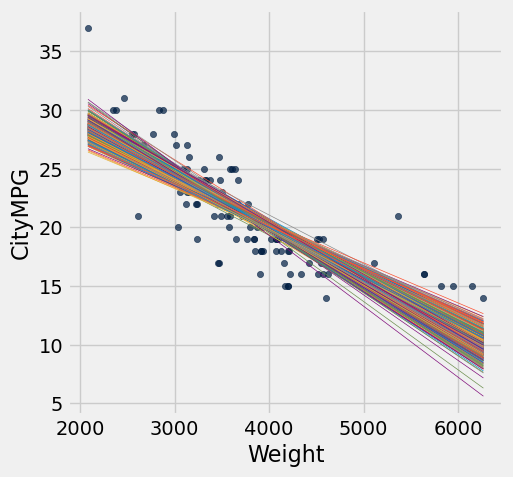

In [4]:
scatter_bootstrap_regression(cars, 500, 'Weight', 'CityMPG')

### Bootstrapping Inference for Slope

157 customers at a restaurant participated in a survey. The amount of the bill and the tip percentage (defined as amount of tip divided by the total bill) were shown in the scatter plot on the top right. 5000 bootstrap samples were taken from the original data, and the slopes of the least square lines were shown in the dot plot on the left. [This applet](https://www.lock5stat.com/StatKey/bootstrap_2_quant/bootstrap_2_quant.html) is used to generate the bootstrap distribution shown in the picture. 

<img src = "boostrap_slope.GIF" width=800>

Based on these bootstrap slopes, the 2.5th percentile was found to be 0.006, while the mean of the bootstrap distribution is 0.049. Can you use these figures and the graph to produce a 95% confidence interval for the slope? 

In [5]:
#97.5th percentile 
0.049 + (0.049 - 0.006)

# 95% confidence interval: (0.006, 0.092)

0.092

Based on your confidence interval, is there evidence to suggest that you can predict the tip percentage from the total amount of the bill? (i.e. the slope is not zero)

In [ ]:
# since 0 is not included, it's possible to predict tip percentage from the total amount (there is correlation)

### Hypothesis Testing for Correlation 

Using bootstrapping, there at least two ways to address whether there is a correlation between two quantitative variables, depending on which version of the null/alternative model you use. 

Null Hypothesis: There is no correlation / The slope of the true line is 0.

Alternative Hypothesis. There is correlation / The slope of the true line is not 0.

Suppose you are using a 5% cutoff for the p-value. You can either construct a bootstrap distribution for $r$, and observe whether the 95% confidence intervals for $r$ and the slope includes 0, respectively. If 0 is inside the interval, then you cannot reject the null hypothesis. 

Using the car data, we can construct a 95% confidence interval for the correlation coefficient $r$ and the slope of the regression line, respectively. 

In [22]:
def bootstrap_r_slope(table, nsamples, xlabel, ylabel):
    r_array = make_array()
    slope_array = make_array()
    for i in np.arange(nsamples):
        resampled_table = table.sample() # default is the same size
        m = slope(resampled_table, xlabel, ylabel) 
        r = correlation(resampled_table, xlabel, ylabel)
        r_array = np.append(r_array, r)
        slope_array = np.append(slope_array, m)
    return r_array, slope_array

rs, slopes = bootstrap_r_slope(cars, 5000, 'Weight', 'PageNum')



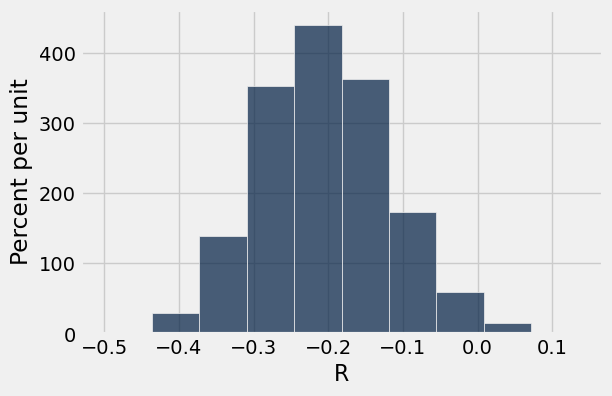

In [23]:
bootstrap_regression_table = Table().with_columns('R', rs, 'Slopes', slopes)

bootstrap_regression_table.hist('R')

In [24]:
percentile(2.5, rs), percentile(97.5, rs)

(-0.36754622847476398, -0.029215503394650358)

Another way to do hypothesis test is to borrow an idea from A/B test, and randomly permute the $Y$ value, while keeping the $X$ values in the original order to generate a randomized version of the original scatter plot. If the null hypothesis is true (there is no correlation, or the slope = 0), then you would expect that randomly paring the X and Y values would provide another equally likely sample from the same population. Each randomized scatter plot then contributes a value for the sampling distribution for $r$ or slope under the null hypothesis. Then p-value is computed either from the left or the right tail. 

Here is a a [good applet](https://www.lock5stat.com/StatKey/randomization_2_quant/randomization_2_quant.html) for visualizing how to randomize under the null hypothesis. 

In [17]:
def randomized_r_slope(table, nsamples, xlabel, ylabel):
    r_array = make_array()
    slope_array = make_array()
    n = table.num_rows
    for i in np.arange(nsamples):
        resampled_table = table.sample(n, with_replacement=False) # do a random permutation
        original_x = table.column(xlabel)
        permuted_y = resampled_table.column(ylabel)
        random_table = Table().with_columns(xlabel, original_x, ylabel, permuted_y)
        m = slope(random_table, xlabel, ylabel) 
        r = correlation(random_table, xlabel, ylabel)
        r_array = np.append(r_array, r)
        slope_array = np.append(slope_array, m)
    return r_array, slope_array

r_array, slope_array = randomized_r_slope(cars, 5000, 'Weight', 'PageNum')

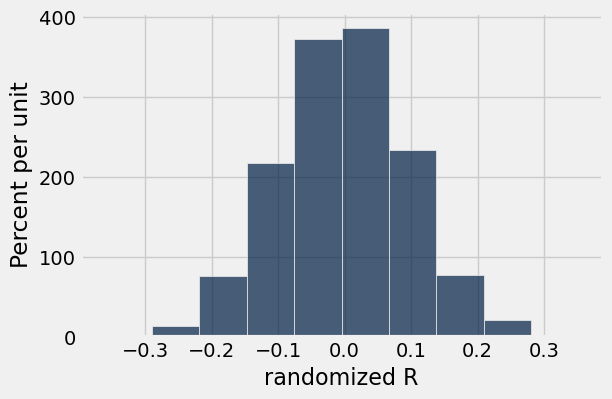

In [18]:
Table().with_column('randomized R', r_array).hist()

In [21]:
actual_r = correlation(cars, 'Weight', 'PageNum')
actual_r
np.count_nonzero(r_array < actual_r) / len(r_array)

0.017

#### Bootstrap Prediction Interval Based on Regresion Lines

If we use the same bootstrapping procedure above to obtain many regression lines, and use each one to make prediction based on a new X value, this will yield a set of predicted Y values. If we use the same procedure to find the confidence interval from the boostrapped predictions, this will yield a boostrap prediction interval. 

Use the following code to generate a 95% prediction interval for vehicles that are 2000, 3000, 4000 and 5000 lbs. Which interval is likely to be most precise? (smallest width)

In [25]:
def bootstrap_prediction(x, table, nsamples, xlabel, ylabel):
    predictions = make_array()
    for i in np.arange(nsamples):
        resampled_table = table.sample() # default is the same size
        m = slope(resampled_table, xlabel, ylabel) 
        b = intercept(resampled_table, xlabel, ylabel)
        predictions = np.append(predictions, m*x+b)
    return predictions


What would the 90% prediction interval for vehicles that are 7000 lbs? What happens as the vehicle's weight increases? 

In [31]:
predicted_MPG = bootstrap_prediction(8114, cars, 2000, 'Weight', 'CityMPG')

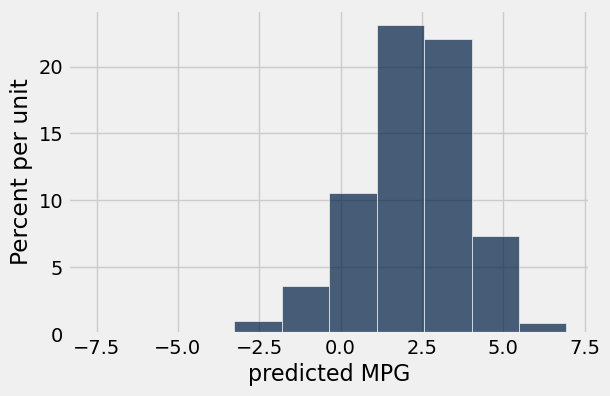

In [32]:
Table().with_column('predicted MPG', predicted_MPG).hist()

In [30]:
percentile(2.5, predicted_MPG), percentile(97.5, predicted_MPG), 

(8.4602964137938628, 11.984569469625647)

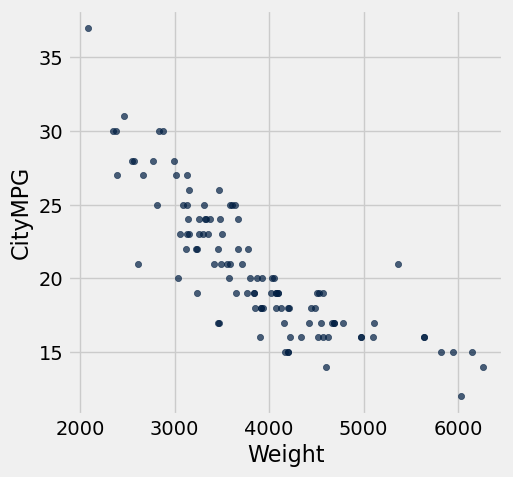

In [34]:
cars.scatter('Weight', 'CityMPG')